In [1]:
import os
import time
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import RobertaModel, RobertaTokenizer


/home/btlab/anaconda3/envs/llm-misinfo/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# 1. Utilities
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def plot_curves(history, out_dir):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_loss"], label="Train")
    plt.plot(epochs, history["val_loss"], label="Val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "loss_curve_cls.png"))
    plt.close()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_acc"], label="Train")
    plt.plot(epochs, history["val_acc"], label="Val")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "accuracy_curve_cls.png"))
    plt.close()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_f1"], label="Train")
    plt.plot(epochs, history["val_f1"], label="Val")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "macro_f1_curve_cls.png"))
    plt.close()


def plot_confusion_matrix(y_true, y_pred, out_path, class_names=None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names if class_names is not None else "auto",
        yticklabels=class_names if class_names is not None else "auto",
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()

In [3]:
# ============================================================
# 2. Interpretable CLS-attention model
# ============================================================

class InterpretableAttentionEmotionModel(nn.Module):
    """
    RoBERTa (frozen) -> CNN -> BiLSTM -> CLS query multihead attention over LSTM outputs.
    Attention weights from the CLS query over tokens are used for explanation.
    """

    def __init__(self, num_classes=6, dropout=0.3):
        super().__init__()

        self.roberta = RobertaModel.from_pretrained("roberta-base")
        for p in self.roberta.parameters():
            p.requires_grad = False

        self.cnn = nn.Conv1d(in_channels=768, out_channels=128, kernel_size=3, padding=1)
        self.maxpool = nn.MaxPool1d(kernel_size=2, stride=2)

        self.bilstm = nn.LSTM(
            input_size=128,
            hidden_size=256,
            num_layers=1,
            bidirectional=True,
            batch_first=True,
        )

        # CLS-style query vector (what the classifier uses to attend over sequence)
        self.cls_query = nn.Parameter(torch.randn(1, 1, 512))  # [1, 1, hidden]

        self.attention = nn.MultiheadAttention(
            embed_dim=512, num_heads=8, dropout=0.1, batch_first=True
        )

        self.dropout = nn.Dropout(dropout)
        self.layernorm = nn.LayerNorm(512)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, input_ids, attention_mask,
                return_attn=False, return_embeddings=False):
        # 1) RoBERTa embeddings
        with torch.no_grad():
            roberta_out = self.roberta(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )
            embeddings = roberta_out.last_hidden_state  # [B, T, 768]

        mask = attention_mask.unsqueeze(-1).float()
        embeddings_masked = embeddings * mask

        # 2) CNN
        x = embeddings_masked.permute(0, 2, 1)   # [B, 768, T]
        x = torch.relu(self.cnn(x))              # [B, 128, T]
        x = x * mask.permute(0, 2, 1)

        # 3) MaxPool
        x = self.maxpool(x)                      # [B, 128, T//2]
        pooled_mask = F.max_pool1d(
            attention_mask.unsqueeze(1).float(),
            kernel_size=2,
            stride=2,
        ).squeeze(1).bool()                      # [B, S]

        # 4) BiLSTM over pooled sequence
        x = x.permute(0, 2, 1)                   # [B, S, 128]
        lstm_out, _ = self.bilstm(x)             # [B, S, 512]

        # 5) CLS-query attention over LSTM outputs
        B, S, H = lstm_out.shape
        # cls_query: [1,1,H] -> expand to [B,1,H]
        q = self.cls_query.expand(B, 1, H).contiguous()
        # MultiheadAttention with query=CLS, key/value=LSTM outputs
        # key_padding_mask: True = ignore (pad)
        attn_out, attn_weights = self.attention(
            q, lstm_out, lstm_out,
            key_padding_mask=~pooled_mask
        )                                        # attn_out: [B,1,512], attn_weights:[B,1,S]

        cls_repr = attn_out.squeeze(1)           # [B,512]
        x = self.dropout(cls_repr)
        x = self.layernorm(x)
        logits = self.fc(x)                      # [B,C]

        if return_attn or return_embeddings:
            out = {"logits": logits}
            if return_attn:
                # attn_weights: [B,1,S] -> attention of CLS over positions
                out["attn_weights"] = attn_weights  # [B,1,S]
                out["pooled_mask"] = pooled_mask
            if return_embeddings:
                out["embeddings"] = embeddings
                out["emb_mask"] = attention_mask
            return out

        return logits


def forward_from_embeddings_cls(model, embeddings, attention_mask):
    """
    Run the part of the InterpretableAttentionEmotionModel starting from embeddings.
    embeddings: [B, T, 768], attention_mask: [B, T]
    """
    mask = attention_mask.unsqueeze(-1).float()
    embeddings_masked = embeddings * mask

    x = embeddings_masked.permute(0, 2, 1)
    x = torch.relu(model.cnn(x))
    x = x * mask.permute(0, 2, 1)

    x = model.maxpool(x)
    pooled_mask = F.max_pool1d(
        attention_mask.unsqueeze(1).float(),
        kernel_size=2,
        stride=2,
    ).squeeze(1).bool()

    x = x.permute(0, 2, 1)
    lstm_out, _ = model.bilstm(x)

    B, S, H = lstm_out.shape
    q = model.cls_query.expand(B, 1, H).contiguous()

    attn_out, _ = model.attention(
        q, lstm_out, lstm_out,
        key_padding_mask=~pooled_mask
    )
    cls_repr = attn_out.squeeze(1)

    x = model.dropout(cls_repr)
    x = model.layernorm(x)
    logits = model.fc(x)
    return logits


In [4]:
# ============================================================
# 3. Dataset and training
# ============================================================

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        enc = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long),
        }


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    all_preds, all_labels = [], []
    total_loss = 0.0
    start_time = time.time()

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1).detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    epoch_time = time.time() - start_time
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, acc, macro_f1, epoch_time


def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    start_time = time.time()

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            total_loss += loss.item() * labels.size(0)

            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    epoch_time = time.time() - start_time
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, acc, macro_f1, np.array(all_labels), np.array(all_preds), epoch_time

In [5]:
# ============================================================
# 4. XAI: attention, IG, hybrid (local explanations)
# ============================================================

def set_train_for_ig(model, train=True):
    if train:
        model.train()
        model.dropout.train(False)
    else:
        model.eval()


def explain_instance_cls(model, tokenizer, text, device,
                         alpha=0.5, m_steps=16, max_length=64):
    """
    Interpretable CLS attention + IG + hybrid for a single instance.
    Returns: tokens, A_tokens, G_tokens, H_tokens, pred_class
    """
    model.eval()
    enc = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )
    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)

    # Forward once to get logits, CLS attention, embeddings
    with torch.no_grad():
        out = model(input_ids, attention_mask,
                    return_attn=True, return_embeddings=True)
    logits = out["logits"]              # [1,C]
    attn_weights = out["attn_weights"]  # [1,1,S]
    pooled_mask = out["pooled_mask"][0] # [S]
    embeddings = out["embeddings"]      # [1,T,768]
    emb_mask = out["emb_mask"][0]       # [T]

    probs = F.softmax(logits, dim=-1)
    pred_class = probs.argmax(dim=-1).item()

    # CLS attention weights over pooled positions
    A_pooled = attn_weights[0, 0, :]             # [S]
    A_pooled = A_pooled * pooled_mask.float()
    A_pooled = A_pooled / (A_pooled.sum() + 1e-8)

    # Integrated Gradients at embedding layer
    set_train_for_ig(model, train=True)
    baseline = torch.zeros_like(embeddings).to(device)
    scaled_embs = []
    for k in range(1, m_steps + 1):
        a = float(k) / m_steps
        scaled_embs.append(baseline + a * (embeddings - baseline))
    scaled_embs = torch.cat(scaled_embs, dim=0)         # [m_steps,T,768]
    scaled_masks = emb_mask.unsqueeze(0).repeat(m_steps, 1).to(device)

    scaled_embs.requires_grad_(True)
    grads_accum = torch.zeros_like(scaled_embs)

    for i in range(m_steps):
        emb_i = scaled_embs[i:i+1].clone().detach().requires_grad_(True)
        mask_i = scaled_masks[i:i+1]
        logits_i = forward_from_embeddings_cls(model, emb_i, mask_i)
        logit_c = logits_i[0, pred_class]
        grads = torch.autograd.grad(logit_c, emb_i, retain_graph=False)[0]
        grads_accum[i] = grads[0].detach()

    set_train_for_ig(model, train=False)

    avg_grads = grads_accum.mean(dim=0)              # [T,768]
    ig = (embeddings[0] - baseline[0]) * avg_grads
    G_tokens = ig.abs().sum(dim=-1)                  # [T]
    G_tokens = G_tokens * emb_mask.float()
    G_tokens = torch.nan_to_num(G_tokens, nan=0.0, posinf=0.0, neginf=0.0)
    G_tokens = G_tokens / (G_tokens.sum() + 1e-8)

    # Map pooled CLS attention to original tokens
    T = emb_mask.size(0)
    S = A_pooled.size(0)
    A_tokens = torch.zeros(T, device=device)
    for i in range(S):
        if not pooled_mask[i]:
            continue
        t1 = 2 * i
        t2 = 2 * i + 1
        if t1 < T:
            A_tokens[t1] += A_pooled[i]
        if t2 < T:
            A_tokens[t2] += A_pooled[i]
    A_tokens = A_tokens * emb_mask.float()
    A_tokens = torch.nan_to_num(A_tokens, nan=0.0, posinf=0.0, neginf=0.0)
    A_tokens = A_tokens / (A_tokens.sum() + 1e-8)

    H_tokens = alpha * A_tokens + (1.0 - alpha) * G_tokens
    H_tokens = torch.nan_to_num(H_tokens, nan=0.0, posinf=0.0, neginf=0.0)

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu().tolist())

    return (
        tokens,
        A_tokens.cpu().numpy(),
        G_tokens.cpu().numpy(),
        H_tokens.cpu().numpy(),
        pred_class,
    )

In [6]:
# ============================================================
# 5. Main training + save (separate directory)
# ============================================================

def main():
    set_seed(42)
    data_path = "text.csv"
    out_dir = "runs_emotion_cls_2"  # NEW directory so old results are preserved
    os.makedirs(out_dir, exist_ok=True)

    print(f">>> Loading data from {data_path}")
    df = pd.read_csv(data_path)
    texts = df["text"].astype(str).tolist()
    labels = df["label"].astype(int).tolist()

    tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
    max_length = 64

    X_train, X_val, y_train, y_val = train_test_split(
        texts,
        labels,
        test_size=0.1,
        stratify=labels,
        random_state=42,
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(">>> Device:", device)
    num_classes = len(set(labels))

    train_dataset = TextDataset(X_train, y_train, tokenizer, max_length=max_length)
    val_dataset = TextDataset(X_val, y_val, tokenizer, max_length=max_length)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    model = InterpretableAttentionEmotionModel(num_classes=num_classes, dropout=0.3).to(device)

    total, trainable = count_parameters(model)
    print(f">>> Total params: {total:,}, trainable: {trainable:,}")

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=2e-4,
        weight_decay=1e-2,
    )

    num_epochs = 50
    best_val_f1 = -1.0
    best_weights_path = os.path.join(out_dir, "best_model_cls.pt")

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_f1": [],
        "val_f1": [],
        "train_time": [],
        "val_time": [],
    }

    print(">>> Starting training (CLS-attention model)...")
    train_start = time.time()

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc, tr_f1, tr_time = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )
        val_loss, val_acc, val_f1, y_true, y_pred, val_time = eval_one_epoch(
            model, val_loader, criterion, device
        )

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(val_acc)
        history["train_f1"].append(tr_f1)
        history["val_f1"].append(val_f1)
        history["train_time"].append(tr_time)
        history["val_time"].append(val_time)

        print(
            f"Epoch {epoch}/{num_epochs} | "
            f"Train L {tr_loss:.4f} A {tr_acc:.4f} F1 {tr_f1:.4f} (time {tr_time:.1f}s) | "
            f"Val L {val_loss:.4f} A {val_acc:.4f} F1 {val_f1:.4f} (time {val_time:.1f}s)"
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), best_weights_path)
            print(f">>> New best model saved to {best_weights_path} (Val F1={val_f1:.4f})")

    total_train_time = time.time() - train_start
    print(f">>> Total training time: {total_train_time/60:.1f} min")

    # Save training history
    hist_df = pd.DataFrame(history)
    hist_df.to_csv(os.path.join(out_dir, "history_cls.csv"), index=False)
    plot_curves(history, out_dir)

    # Confusion matrix on validation
    cm_path = os.path.join(out_dir, "confusion_matrix_val_cls.png")
    plot_confusion_matrix(y_true, y_pred, cm_path,
                          class_names=sorted(set(labels)))
    print(f">>> Confusion matrix saved to {cm_path}")

    # Save a few example explanations for inspection
    print(">>> Saving example CLS-attention + IG + hybrid explanations...")
    expl_records = []
    for i, text in enumerate(X_val[:10]):
        tokens, A, G, H, pred_class = explain_instance_cls(
            model, tokenizer, text, device,
            alpha=0.5, m_steps=16, max_length=max_length
        )
        expl_records.append({
            "text": text,
            "tokens": " ".join(tokens),
            "attention_scores": " ".join([f"{v:.4f}" for v in A]),
            "ig_scores": " ".join([f"{v:.4f}" for v in G]),
            "hybrid_scores": " ".join([f"{v:.4f}" for v in H]),
            "pred_class": pred_class,
        })
    pd.DataFrame(expl_records).to_csv(
        os.path.join(out_dir, "example_explanations_cls_attention_ig_hybrid.csv"),
        index=False,
    )
    print(">>> Example explanations saved.")

In [7]:
if __name__ == "__main__":
    print(">>> About to train CLS-attention model")
    main()
    print(">>> Done.")

>>> About to train CLS-attention model
>>> Loading data from text.csv
>>> Device: cuda


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 17671.75it/s]
RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


>>> Total params: 126,786,438, trainable: 2,140,806
>>> Starting training (CLS-attention model)...
Epoch 1/50 | Train L 0.3953 A 0.8503 F1 0.8065 (time 366.7s) | Val L 0.1896 A 0.9138 F1 0.8809 (time 39.2s)
>>> New best model saved to runs_emotion_cls_2/best_model_cls.pt (Val F1=0.8809)
Epoch 2/50 | Train L 0.2214 A 0.9052 F1 0.8704 (time 387.5s) | Val L 0.1663 A 0.9225 F1 0.8957 (time 39.9s)
>>> New best model saved to runs_emotion_cls_2/best_model_cls.pt (Val F1=0.8957)


KeyboardInterrupt: 

## Evaluation and XAI

In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from scipy.stats import spearmanr

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import RobertaModel, RobertaTokenizer


# ============================================================
# 1. Utilities
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def plot_confusion_matrix(y_true, y_pred, out_path, class_names=None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names if class_names is not None else "auto",
        yticklabels=class_names if class_names is not None else "auto",
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()


# ============================================================
# 2. CLS-attention model (same as in training script)
# ============================================================

class InterpretableAttentionEmotionModel(nn.Module):
    def __init__(self, num_classes=6, dropout=0.3):
        super().__init__()

        self.roberta = RobertaModel.from_pretrained("roberta-base")
        for p in self.roberta.parameters():
            p.requires_grad = False

        self.cnn = nn.Conv1d(in_channels=768, out_channels=128, kernel_size=3, padding=1)
        self.maxpool = nn.MaxPool1d(kernel_size=2, stride=2)

        self.bilstm = nn.LSTM(
            input_size=128,
            hidden_size=256,
            num_layers=1,
            bidirectional=True,
            batch_first=True,
        )

        self.cls_query = nn.Parameter(torch.randn(1, 1, 512))

        self.attention = nn.MultiheadAttention(
            embed_dim=512, num_heads=8, dropout=0.1, batch_first=True
        )

        self.dropout = nn.Dropout(dropout)
        self.layernorm = nn.LayerNorm(512)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, input_ids, attention_mask,
                return_attn=False, return_embeddings=False):
        with torch.no_grad():
            roberta_out = self.roberta(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )
            embeddings = roberta_out.last_hidden_state  # [B, T, 768]

        mask = attention_mask.unsqueeze(-1).float()
        embeddings_masked = embeddings * mask

        x = embeddings_masked.permute(0, 2, 1)   # [B, 768, T]
        x = torch.relu(self.cnn(x))              # [B, 128, T]
        x = x * mask.permute(0, 2, 1)

        x = self.maxpool(x)                      # [B, 128, T//2]
        pooled_mask = F.max_pool1d(
            attention_mask.unsqueeze(1).float(),
            kernel_size=2,
            stride=2,
        ).squeeze(1).bool()                      # [B, S]

        x = x.permute(0, 2, 1)                   # [B, S, 128]
        lstm_out, _ = self.bilstm(x)             # [B, S, 512]

        B, S, H = lstm_out.shape
        q = self.cls_query.expand(B, 1, H).contiguous()

        attn_out, attn_weights = self.attention(
            q, lstm_out, lstm_out,
            key_padding_mask=~pooled_mask
        )                                        # attn_out: [B,1,512], attn_weights: [B,1,S]

        cls_repr = attn_out.squeeze(1)           # [B,512]
        x = self.dropout(cls_repr)
        x = self.layernorm(x)
        logits = self.fc(x)                      # [B,C]

        if return_attn or return_embeddings:
            out = {"logits": logits}
            if return_attn:
                out["attn_weights"] = attn_weights
                out["pooled_mask"] = pooled_mask
            if return_embeddings:
                out["embeddings"] = embeddings
                out["emb_mask"] = attention_mask
            return out

        return logits


def forward_from_embeddings_cls(model, embeddings, attention_mask):
    mask = attention_mask.unsqueeze(-1).float()
    embeddings_masked = embeddings * mask

    x = embeddings_masked.permute(0, 2, 1)
    x = torch.relu(model.cnn(x))
    x = x * mask.permute(0, 2, 1)

    x = model.maxpool(x)
    pooled_mask = F.max_pool1d(
        attention_mask.unsqueeze(1).float(),
        kernel_size=2,
        stride=2,
    ).squeeze(1).bool()

    x = x.permute(0, 2, 1)
    lstm_out, _ = model.bilstm(x)

    B, S, H = lstm_out.shape
    q = model.cls_query.expand(B, 1, H).contiguous()

    attn_out, _ = model.attention(
        q, lstm_out, lstm_out,
        key_padding_mask=~pooled_mask
    )
    cls_repr = attn_out.squeeze(1)

    x = model.dropout(cls_repr)
    x = model.layernorm(x)
    logits = model.fc(x)
    return logits


# ============================================================
# 3. Dataset and basic eval
# ============================================================

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        enc = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long),
        }


def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    start_time = time.time()

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            total_loss += loss.item() * labels.size(0)

            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    epoch_time = time.time() - start_time
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, acc, macro_f1, np.array(all_labels), np.array(all_preds), epoch_time


# ============================================================
# 4. XAI: CLS attention, IG, hybrid
# ============================================================

def set_train_for_ig(model, train=True):
    if train:
        model.train()
        model.dropout.train(False)
    else:
        model.eval()


def explain_instance_cls(model, tokenizer, text, device,
                         alpha=0.5, m_steps=16, max_length=64):
    """
    Return tokens, CLS-attention (A), IG (G), hybrid (H), pred_class for a single text.
    """
    model.eval()
    enc = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )
    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)

    with torch.no_grad():
        out = model(input_ids, attention_mask,
                    return_attn=True, return_embeddings=True)
    logits = out["logits"]
    attn_weights = out["attn_weights"]   # [1,1,S]
    pooled_mask = out["pooled_mask"][0] # [S]
    embeddings = out["embeddings"]      # [1,T,768]
    emb_mask = out["emb_mask"][0]       # [T]

    probs = F.softmax(logits, dim=-1)
    pred_class = probs.argmax(dim=-1).item()

    # CLS attention over pooled positions
    A_pooled = attn_weights[0, 0, :]             # [S]
    A_pooled = A_pooled * pooled_mask.float()
    A_pooled = A_pooled / (A_pooled.sum() + 1e-8)

    # Integrated Gradients
    set_train_for_ig(model, train=True)
    baseline = torch.zeros_like(embeddings).to(device)
    scaled_embs = []
    for k in range(1, m_steps + 1):
        a = float(k) / m_steps
        scaled_embs.append(baseline + a * (embeddings - baseline))
    scaled_embs = torch.cat(scaled_embs, dim=0)         # [m_steps,T,768]
    scaled_masks = emb_mask.unsqueeze(0).repeat(m_steps, 1).to(device)

    scaled_embs.requires_grad_(True)
    grads_accum = torch.zeros_like(scaled_embs)

    for i in range(m_steps):
        emb_i = scaled_embs[i:i+1].clone().detach().requires_grad_(True)
        mask_i = scaled_masks[i:i+1]
        logits_i = forward_from_embeddings_cls(model, emb_i, mask_i)
        logit_c = logits_i[0, pred_class]
        grads = torch.autograd.grad(logit_c, emb_i, retain_graph=False)[0]
        grads_accum[i] = grads[0].detach()

    set_train_for_ig(model, train=False)

    avg_grads = grads_accum.mean(dim=0)              # [T,768]
    ig = (embeddings[0] - baseline[0]) * avg_grads
    G_tokens = ig.abs().sum(dim=-1)                  # [T]
    G_tokens = G_tokens * emb_mask.float()
    G_tokens = torch.nan_to_num(G_tokens, nan=0.0, posinf=0.0, neginf=0.0)
    G_tokens = G_tokens / (G_tokens.sum() + 1e-8)

    # Map pooled attention to tokens
    T = emb_mask.size(0)
    S = A_pooled.size(0)
    A_tokens = torch.zeros(T, device=device)
    for i in range(S):
        if not pooled_mask[i]:
            continue
        t1 = 2 * i
        t2 = 2 * i + 1
        if t1 < T:
            A_tokens[t1] += A_pooled[i]
        if t2 < T:
            A_tokens[t2] += A_pooled[i]
    A_tokens = A_tokens * emb_mask.float()
    A_tokens = torch.nan_to_num(A_tokens, nan=0.0, posinf=0.0, neginf=0.0)
    A_tokens = A_tokens / (A_tokens.sum() + 1e-8)

    H_tokens = alpha * A_tokens + (1.0 - alpha) * G_tokens
    H_tokens = torch.nan_to_num(H_tokens, nan=0.0, posinf=0.0, neginf=0.0)

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu().tolist())

    return (
        tokens,
        A_tokens.cpu().numpy(),
        G_tokens.cpu().numpy(),
        H_tokens.cpu().numpy(),
        pred_class,
    )


# ============================================================
# 5. Global analysis: attention–IG correlation and class-wise tokens
# ============================================================

def compute_attention_ig_correlations(model, tokenizer, texts, device,
                                      max_length=64, max_examples=None):
    """
    Compute Spearman correlation between attention ranks and IG ranks per instance.
    Returns list of correlations (ignoring examples where correlation is undefined).
    """
    if max_examples is not None:
        texts = texts[:max_examples]

    corrs = []
    for text in texts:
        tokens, A, G, H, pred_class = explain_instance_cls(
            model, tokenizer, text, device,
            alpha=0.5, m_steps=16, max_length=max_length
        )
        # restrict to non-zero tokens (avoid pad tail)
        L = len(tokens)
        mask = (A + G) > 0
        if mask.sum() < 3:
            continue
        A_valid = A[mask]
        G_valid = G[mask]
        if np.all(A_valid == A_valid[0]) or np.all(G_valid == G_valid[0]):
            # constant vector → undefined Spearman
            continue
        rho, _ = spearmanr(A_valid, G_valid)
        if np.isfinite(rho):
            corrs.append(rho)
    return corrs


def classwise_top_tokens(model, tokenizer, texts, labels, device,
                         max_length=64, max_examples=None, top_k=20):
    """
    Aggregate IG and hybrid scores per token per class and return class-wise top tokens.
    """
    if max_examples is not None:
        texts = texts[:max_examples]
        labels = labels[:max_examples]

    class_ids = sorted(set(labels))
    per_class_ig = {c: {} for c in class_ids}
    per_class_h = {c: {} for c in class_ids}

    for text, y in zip(texts, labels):
        tokens, A, G, H, pred_class = explain_instance_cls(
            model, tokenizer, text, device,
            alpha=0.5, m_steps=16, max_length=max_length
        )
        # you can choose to aggregate by true label y or predicted class
        cls = y

        for tok, g, h in zip(tokens, G, H):
            if g <= 0 and h <= 0:
                continue
            # skip pads
            if tok == "<pad>":
                continue
            per_class_ig[cls][tok] = per_class_ig[cls].get(tok, 0.0) + float(g)
            per_class_h[cls][tok] = per_class_h[cls].get(tok, 0.0) + float(h)

    # build dataframes
    rows = []
    for cls in class_ids:
        ig_dict = per_class_ig[cls]
        h_dict = per_class_h[cls]

        top_ig = sorted(ig_dict.items(), key=lambda x: -x[1])[:top_k]
        top_h = sorted(h_dict.items(), key=lambda x: -x[1])[:top_k]

        for tok, score in top_ig:
            rows.append({"class": cls, "token": tok, "score_type": "IG", "score": score})
        for tok, score in top_h:
            rows.append({"class": cls, "token": tok, "score_type": "hybrid", "score": score})

    df = pd.DataFrame(rows)
    return df


# ============================================================
# 6. Main evaluation + XAI
# ============================================================

def main():
    set_seed(42)
    data_path = "text.csv"
    out_dir = "runs_emotion_cls_2"
    best_weights_path = os.path.join(out_dir, "best_model_cls.pt")
    os.makedirs(out_dir, exist_ok=True)

    print(f">>> Loading data from {data_path}")
    df = pd.read_csv(data_path)
    texts = df["text"].astype(str).tolist()
    labels = df["label"].astype(int).tolist()

    tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
    max_length = 64

    # same split as training (must match)
    X_train, X_test, y_train, y_test = train_test_split(
        texts,
        labels,
        test_size=0.1,
        stratify=labels,
        random_state=42,
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(">>> Using device:", device)
    num_classes = len(set(labels))

    print(">>> Building CLS-attention model and loading weights ...")
    model = InterpretableAttentionEmotionModel(num_classes=num_classes, dropout=0.3).to(device)
    state_dict = torch.load(best_weights_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    print(f">>> Loaded best CLS model from {best_weights_path}")

    # Basic test evaluation
    test_dataset = TextDataset(X_test, y_test, tokenizer, max_length=max_length)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    criterion = nn.CrossEntropyLoss()

    test_loss, test_acc, test_f1, y_true, y_pred, test_time = eval_one_epoch(
        model, test_loader, criterion, device
    )
    print(
        f">>> CLS Test → Loss {test_loss:.4f}, "
        f"Acc {test_acc:.4f}, Macro-F1 {test_f1:.4f}, "
        f"EvalTime {test_time:.2f}s"
    )

    cm_path = os.path.join(out_dir, "confusion_matrix_test_cls.png")
    plot_confusion_matrix(y_true, y_pred, cm_path,
                          class_names=sorted(set(labels)))
    print(f">>> Confusion matrix saved to {cm_path}")

    # Local explanations: save a few example rows
    print(">>> Saving example CLS-attention + IG + hybrid explanations...")
    records = []
    num_examples = min(500, len(X_test)) # changed from 20 to 500 to capture richer representation
    for i in range(num_examples):
        text = X_test[i]
        tokens, A, G, H, pred_class = explain_instance_cls(
            model, tokenizer, text, device,
            alpha=0.5, m_steps=16, max_length=max_length
        )
        records.append({
            "text": text,
            "tokens": " ".join(tokens),
            "attention_scores": " ".join([f"{v:.4f}" for v in A]),
            "ig_scores": " ".join([f"{v:.4f}" for v in G]),
            "hybrid_scores": " ".join([f"{v:.4f}" for v in H]),
            "pred_class": pred_class,
            "true_label": y_test[i],
        })
    df_examples = pd.DataFrame(records)
    examples_path = os.path.join(out_dir, "example_explanations_cls_attention_ig_hybrid_test.csv")
    df_examples.to_csv(examples_path, index=False)
    print(f">>> Example explanations saved to {examples_path}")

    # Global correlation: attention vs IG
    print(">>> Computing attention–IG Spearman correlations...")
    corrs = compute_attention_ig_correlations(
        model, tokenizer, X_test, device,
        max_length=max_length, max_examples=None
    ) # max_example=None is used to include all test examples
    if corrs:
        print(f"    Num examples: {len(corrs)}")
        print(f"    Mean rho: {np.mean(corrs):.4f}, "
              f"Median rho: {np.median(corrs):.4f}, "
              f"Std: {np.std(corrs):.4f}")
        corr_df = pd.DataFrame({"spearman_rho": corrs})
        corr_df.to_csv(os.path.join(out_dir, "attention_ig_spearman_cls.csv"), index=False)
    else:
        print("    No valid correlations computed (check masks/constants).")

    # Class-wise top tokens (IG and hybrid)
    print(">>> Computing class-wise top tokens (IG and hybrid)...")
    df_class_tokens = classwise_top_tokens(
        model, tokenizer, X_test, y_test, device,
        max_length=max_length, max_examples=None, top_k=20
    )
    class_tokens_path = os.path.join(out_dir, "classwise_top_tokens_ig_hybrid_cls.csv")
    df_class_tokens.to_csv(class_tokens_path, index=False)
    print(f">>> Class-wise token stats saved to {class_tokens_path}")

    print(">>> Evaluation + XAI (CLS model) finished.")


if __name__ == "__main__":
    print(">>> Starting evaluate_xai_cls.py ...")
    main()
    print(">>> Done.")

>>> Starting evaluate_xai_cls.py ...
>>> Loading data from text.csv
>>> Using device: cuda
>>> Building CLS-attention model and loading weights ...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 17273.50it/s]
RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_444006/3747163113.py:450: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the defau

>>> Loaded best CLS model from runs_emotion_cls/best_model_cls.pt
>>> CLS Test → Loss 0.1243, Acc 0.9289, Macro-F1 0.9001, EvalTime 35.77s
>>> Confusion matrix saved to runs_emotion_cls/confusion_matrix_test_cls.png
>>> Saving example CLS-attention + IG + hybrid explanations...
>>> Example explanations saved to runs_emotion_cls/example_explanations_cls_attention_ig_hybrid_test.csv
>>> Computing attention–IG Spearman correlations...
    Num examples: 200
    Mean rho: 0.5708, Median rho: 0.6137, Std: 0.1921
>>> Computing class-wise top tokens (IG and hybrid)...
>>> Class-wise token stats saved to runs_emotion_cls/classwise_top_tokens_ig_hybrid_cls.csv
>>> Evaluation + XAI (CLS model) finished.
>>> Done.


# MoRF/Deletion Curves: Faitfulness

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 15525.41it/s]
RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_444006/291541646.py:170: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the defaul

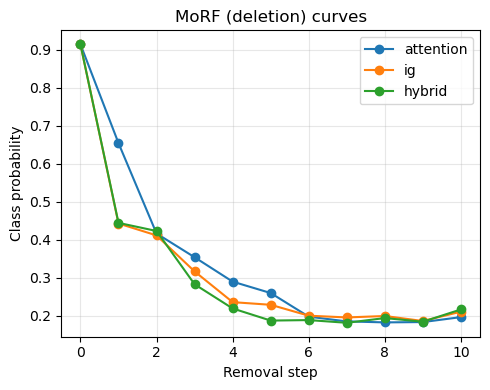

Saved MoRF curves to runs_emotion_cls/morf_curves_cls.png
attention AUC = 3.280882648471743
ig AUC = 2.9822291445641893
hybrid AUC = 2.8735991670473595


In [ ]:
import os
import time
import random
import numpy as np
from numpy import trapezoid
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import RobertaModel, RobertaTokenizer

# ============================================================
# CONFIG
# ============================================================

SEED = 42
OUT_DIR = "runs_emotion_cls_2"
BEST_WEIGHTS_PATH = os.path.join(OUT_DIR, "best_model_cls.pt")
EXPL_CSV_PATH = os.path.join(
    OUT_DIR, "example_explanations_cls_attention_ig_hybrid_test.csv"
)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LENGTH = 64
NUM_STEPS = 10
MAX_EXAMPLES = 1000
NUM_CLASSES = 6  # adjust if needed

# ============================================================
# UTILITIES
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# ============================================================
# MODEL (same as your InterpretableAttentionEmotionModel)
# ============================================================

class InterpretableAttentionEmotionModel(nn.Module):
    def __init__(self, num_classes=6, dropout=0.3):
        super().__init__()

        self.roberta = RobertaModel.from_pretrained("roberta-base")
        for p in self.roberta.parameters():
            p.requires_grad = False

        self.cnn = nn.Conv1d(in_channels=768, out_channels=128, kernel_size=3, padding=1)
        self.maxpool = nn.MaxPool1d(kernel_size=2, stride=2)

        self.bilstm = nn.LSTM(
            input_size=128,
            hidden_size=256,
            num_layers=1,
            bidirectional=True,
            batch_first=True,
        )

        self.cls_query = nn.Parameter(torch.randn(1, 1, 512))

        self.attention = nn.MultiheadAttention(
            embed_dim=512, num_heads=8, dropout=0.1, batch_first=True
        )

        self.dropout = nn.Dropout(dropout)
        self.layernorm = nn.LayerNorm(512)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, input_ids, attention_mask,
                return_attn=False, return_embeddings=False):
        with torch.no_grad():
            roberta_out = self.roberta(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )
            embeddings = roberta_out.last_hidden_state  # [B, T, 768]

        mask = attention_mask.unsqueeze(-1).float()
        embeddings_masked = embeddings * mask

        x = embeddings_masked.permute(0, 2, 1)   # [B, 768, T]
        x = torch.relu(self.cnn(x))              # [B, 128, T]
        x = x * mask.permute(0, 2, 1)

        x = self.maxpool(x)                      # [B, 128, T//2]
        pooled_mask = F.max_pool1d(
            attention_mask.unsqueeze(1).float(),
            kernel_size=2,
            stride=2,
        ).squeeze(1).bool()                      # [B, S]

        x = x.permute(0, 2, 1)                   # [B, S, 128]
        lstm_out, _ = self.bilstm(x)             # [B, S, 512]

        B, S, H = lstm_out.shape
        q = self.cls_query.expand(B, 1, H).contiguous()

        attn_out, attn_weights = self.attention(
            q, lstm_out, lstm_out,
            key_padding_mask=~pooled_mask
        )                                       # attn_out: [B,1,512], attn_weights:[B,1,S]

        cls_repr = attn_out.squeeze(1)          # [B,512]
        x = self.dropout(cls_repr)
        x = self.layernorm(x)
        logits = self.fc(x)                     # [B,C]

        if return_attn or return_embeddings:
            out = {"logits": logits}
            if return_attn:
                out["attn_weights"] = attn_weights
                out["pooled_mask"] = pooled_mask
            if return_embeddings:
                out["embeddings"] = embeddings
                out["emb_mask"] = attention_mask
            return out

        return logits

def forward_from_embeddings_cls(model, embeddings, attention_mask):
    mask = attention_mask.unsqueeze(-1).float()
    embeddings_masked = embeddings * mask

    x = embeddings_masked.permute(0, 2, 1)
    x = torch.relu(model.cnn(x))
    x = x * mask.permute(0, 2, 1)

    x = model.maxpool(x)
    pooled_mask = F.max_pool1d(
        attention_mask.unsqueeze(1).float(),
        kernel_size=2,
        stride=2,
    ).squeeze(1).bool()

    x = x.permute(0, 2, 1)
    lstm_out, _ = model.bilstm(x)

    B, S, H = lstm_out.shape
    q = model.cls_query.expand(B, 1, H).contiguous()

    attn_out, _ = model.attention(
        q, lstm_out, lstm_out,
        key_padding_mask=~pooled_mask
    )
    cls_repr = attn_out.squeeze(1)

    x = model.dropout(cls_repr)
    x = model.layernorm(x)
    logits = model.fc(x)
    return logits

# ============================================================
# LOAD MODEL & TOKENIZER
# ============================================================

os.makedirs(OUT_DIR, exist_ok=True)

tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
model = InterpretableAttentionEmotionModel(num_classes=NUM_CLASSES, dropout=0.3).to(DEVICE)
state_dict = torch.load(BEST_WEIGHTS_PATH, map_location=DEVICE)
model.load_state_dict(state_dict)
model.eval()

MASK_TOKEN = tokenizer.mask_token if tokenizer.mask_token is not None else "<mask>"

# ============================================================
# LOAD EXPLANATIONS CSV
# ============================================================

df = pd.read_csv(EXPL_CSV_PATH)

def parse_scores(scores_str):
    return np.array([float(x) for x in str(scores_str).strip().split()])

texts = df["text"].tolist()
attribs = []

for _, row in df.iterrows():
    tokens = str(row["tokens"]).split()
    A = parse_scores(row["attention_scores"])
    G = parse_scores(row["ig_scores"])
    H = parse_scores(row["hybrid_scores"])

    # trim at first <pad>
    if "<pad>" in tokens:
        cutoff = tokens.index("<pad>")
        tokens = tokens[:cutoff]
        A = A[:cutoff]
        G = G[:cutoff]
        H = H[:cutoff]

    # drop <s>, </s>
    keep_idx = [i for i, tok in enumerate(tokens) if tok not in ["<s>", "</s>"]]
    tokens = [tokens[i] for i in keep_idx]
    A = A[keep_idx]
    G = G[keep_idx]
    H = H[keep_idx]

    attribs.append({"tokens": tokens, "attention": A, "ig": G, "hybrid": H})

# ============================================================
# MoRF FUNCTIONS
# ============================================================

@torch.no_grad()
def get_class_prob(model, input_ids, attention_mask, target_class=None):
    out = model(input_ids, attention_mask)
    logits = out if isinstance(out, torch.Tensor) else out["logits"]
    logits = logits.squeeze(0)
    probs = torch.softmax(logits, dim=-1)
    if target_class is None:
        target_class = int(torch.argmax(probs))
    return float(probs[target_class]), target_class

def mask_tokens(input_ids, mask_indices, tokenizer, mask_token):
    ids = input_ids.clone()
    mask_id = tokenizer.convert_tokens_to_ids(mask_token)
    ids[mask_indices] = mask_id
    return ids

def morf_curve_example(model, tokenizer, text, scores_dict,
                       max_length=64, num_steps=10,
                       mask_token="<mask>", device=DEVICE):
    enc = tokenizer(
        text,
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )
    input_ids = enc["input_ids"][0].to(device)
    attn_mask = enc["attention_mask"][0].to(device)

    pad_id = tokenizer.pad_token_id
    if pad_id is None:
        nonpad = list(range(input_ids.size(0)))
    else:
        nonpad = (input_ids != pad_id).nonzero(as_tuple=True)[0].tolist()
    if len(nonpad) < 3:
        return None

    cls_pos = nonpad[0]
    sep_pos = nonpad[-1]
    token_positions = [i for i in nonpad if i not in [cls_pos, sep_pos]]

    T = len(token_positions)
    for m in scores_dict:
        if len(scores_dict[m]) != T:
            return None

    base_prob, target_class = get_class_prob(
        model, input_ids.unsqueeze(0), attn_mask.unsqueeze(0), target_class=None
    )

    probs_dict = {m: [] for m in scores_dict}
    k_per_step = max(1, T // num_steps)

    for m, scores in scores_dict.items():
        scores = np.array(scores)
        order = np.argsort(-scores)

        probs = [base_prob]
        for step in range(1, num_steps + 1):
            k = min(step * k_per_step, T)
            mask_abs = [token_positions[j] for j in order[:k]]
            masked_ids = mask_tokens(input_ids, mask_abs, tokenizer, mask_token)
            p_step, _ = get_class_prob(
                model,
                masked_ids.unsqueeze(0),
                attn_mask.unsqueeze(0),
                target_class=target_class
            )
            probs.append(p_step)
        probs_dict[m] = probs

    return probs_dict

def morf_curves(model, tokenizer, texts, attribs,
                max_length=64, num_steps=10,
                mask_token="<mask>", device=DEVICE,
                max_examples=1000): # changed from 200
    methods = ["attention", "ig", "hybrid"]
    curves_sum = {m: np.zeros(num_steps + 1) for m in methods}
    counts = {m: 0 for m in methods}

    n = min(len(texts), max_examples)
    for i in tqdm(range(n), desc="MoRF"):
        text = texts[i]
        a = attribs[i]
        scores_dict = {m: a[m] for m in methods}
        res = morf_curve_example(
            model, tokenizer, text, scores_dict,
            max_length=max_length, num_steps=num_steps,
            mask_token=mask_token, device=device
        )
        if res is None:
            continue
        for m in methods:
            curves_sum[m] += np.array(res[m])
            counts[m] += 1

    curves_avg = {}
    for m in methods:
        if counts[m] > 0:
            curves_avg[m] = curves_sum[m] / counts[m]
        else:
            curves_avg[m] = None
    return curves_avg

def plot_morf(curves, num_steps=10, path=None):
    xs = np.arange(num_steps + 1)
    plt.figure(figsize=(5, 4))
    for m, curve in curves.items():
        if curve is None:
            continue
        plt.plot(xs, curve, marker="o", label=m)
    plt.xlabel("Removal step")
    plt.ylabel("Class probability")
    plt.title("MoRF (deletion) curves")
    plt.legend()
    plt.grid(True, alpha=0.3)
    if path:
        plt.tight_layout()
        plt.savefig(path, dpi=300)
    plt.show()

def auc_trapz(curve):
    xs = np.arange(len(curve))
    return trapezoid(curve, xs)

# ============================================================
# RUN MORF
# ============================================================

curves = morf_curves(
    model, tokenizer, texts, attribs,
    max_length=MAX_LENGTH,
    num_steps=NUM_STEPS,
    mask_token=MASK_TOKEN,
    device=DEVICE,
    max_examples=MAX_EXAMPLES
)

plot_path = os.path.join(OUT_DIR, "morf_curves_cls.png")
plot_morf(curves, num_steps=NUM_STEPS, path=plot_path)
print(f"Saved MoRF curves to {plot_path}")

for m, c in curves.items():
    if c is not None:
        print(m, "AUC =", auc_trapz(c))